In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
plt.rcParams.update({
    "figure.figsize": (12, 6),
    "figure.dpi": 100,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

out_dir = '/kaggle/working/opstat_1'
os.makedirs(out_dir, exist_ok=True)
print(f"Folder output disiapkan di: {out_dir}")

Folder output disiapkan di: /kaggle/working/opstat_1


In [ ]:
data_path = '/kaggle/input/datasets/fauzanrasendriya/spline-opstat/Data_Opstat_Spline.xlsx'

df = pd.read_excel(data_path)
df['Tanggal'] = pd.to_datetime(df['Tanggal'])
df = df.sort_values('Tanggal')
df.set_index('Tanggal', inplace=True)

df.rename(columns={'Kurs': 'Y'}, inplace=True)

if 'Keterangan' in df.columns:
    df.drop(columns=['Keterangan'], inplace=True)

print("Data berhasil dimuat!")
display(df.head())

Data berhasil dimuat!


,Y
Tanggal,
2015-01-02,12474.000000
2015-01-03,12502.556996
2015-01-04,12539.037997
2015-01-05,12589.000000
2015-01-06,12658.000000


In [4]:
# 1. Pengecekan Missing Values
print("Pengecekan Missing Values:")
print(df.isnull().sum())
print("-" * 30)

Pengecekan Missing Values:
Y    0
dtype: int64
------------------------------


In [5]:
# 2. Statistik Deskriptif
print("\nStatistik Deskriptif Nilai Kurs (Y):")
display(df.describe())


Statistik Deskriptif Nilai Kurs (Y):


,Y
count,4017.000000
mean,14526.938275
std,1049.365944
min,12444.000000
25%,13650.000000
50%,14348.000000
75%,15293.000000
max,16943.000000


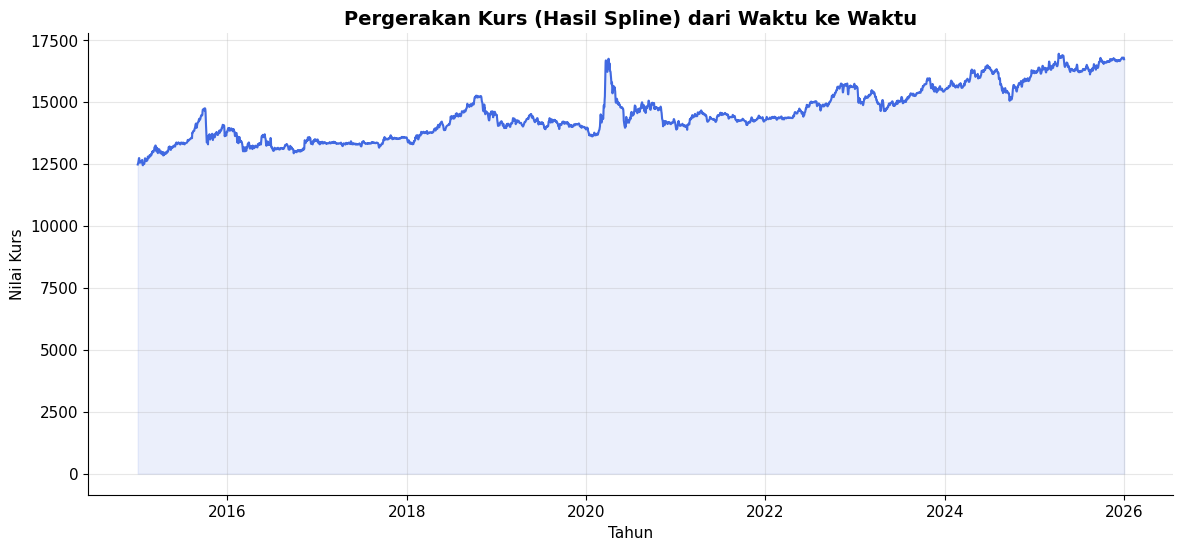

In [6]:
# 3. Visualisasi Tren Kurs Keseluruhan
plt.figure(figsize=(14, 6))
plt.plot(df.index, df['Y'], color='royalblue', linewidth=1.5)
plt.title('Pergerakan Kurs (Hasil Spline) dari Waktu ke Waktu', fontsize=14, fontweight='bold')
plt.xlabel('Tahun')
plt.ylabel('Nilai Kurs')
plt.fill_between(df.index, df['Y'], alpha=0.1, color='royalblue')
plt.show()

Total Data: 4017 observasi
Data Train: 3213 observasi (2015-01-02 hingga 2023-10-19)
Data Val  : 402 observasi (2023-10-20 hingga 2024-11-24)
Data Test : 402 observasi (2024-11-25 hingga 2025-12-31)


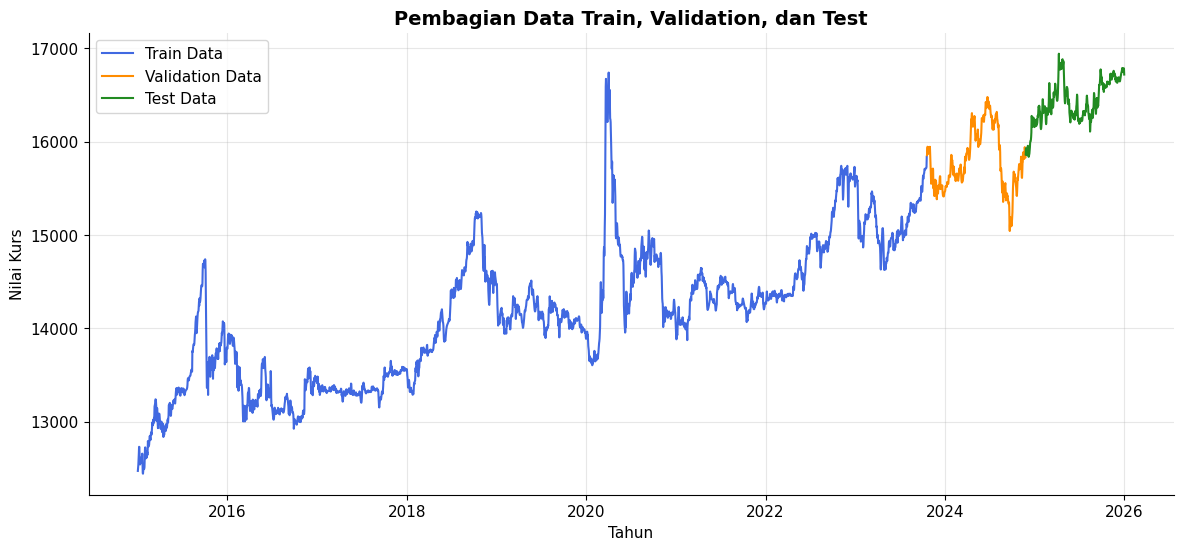

In [7]:
total_data = len(df)

# Menentukan batas indeks untuk split (80% Train, 10% Val, 10% Test)
train_end = int(total_data * 0.8)
val_end = int(total_data * 0.9)

# Melakukan Slicing
train_df = df.iloc[:train_end]
val_df = df.iloc[train_end:val_end]
test_df = df.iloc[val_end:]

print(f"Total Data: {total_data} observasi")
print(f"Data Train: {len(train_df)} observasi ({train_df.index[0].date()} hingga {train_df.index[-1].date()})")
print(f"Data Val  : {len(val_df)} observasi ({val_df.index[0].date()} hingga {val_df.index[-1].date()})")
print(f"Data Test : {len(test_df)} observasi ({test_df.index[0].date()} hingga {test_df.index[-1].date()})")

# Visualisasi Pembagian Data
plt.figure(figsize=(14, 6))
plt.plot(train_df.index, train_df['Y'], label='Train Data', color='royalblue')
plt.plot(val_df.index, val_df['Y'], label='Validation Data', color='darkorange')
plt.plot(test_df.index, test_df['Y'], label='Test Data', color='forestgreen')
plt.title('Pembagian Data Train, Validation, dan Test', fontsize=14, fontweight='bold')
plt.xlabel('Tahun')
plt.ylabel('Nilai Kurs')
plt.legend()
plt.show()

In [8]:
# Menyimpan file ke Kaggle Working Directory
train_df.to_csv(os.path.join(out_dir, "train.csv"))
val_df.to_csv(os.path.join(out_dir, "val.csv"))
test_df.to_csv(os.path.join(out_dir, "test.csv"))

print(f"Data berhasil disimpan di direktori: {out_dir}")
print("Silakan klik 'Save Version' -> 'Save & Run All (Commit)' untuk menyimpan output notebook ini.")

Data berhasil disimpan di direktori: /kaggle/working/opstat_1
Silakan klik 'Save Version' -> 'Save & Run All (Commit)' untuk menyimpan output notebook ini.
